# Attendance System
Run the cells in order. Change `IMAGE_PATH` in Cell 2 to your photo path.

In [ ]:
import cv2
import numpy as np
import pickle
import csv
import os
from datetime import datetime
from pathlib import Path

#CONFIG
IMAGE_PATH    = "test.jpg"       # <-- change this to your image path
EMBEDDINGS    = "embeddings.pkl" # saved from training notebook
MODEL_PATH    = "model.pkl"      # saved from training notebook
ATTENDANCE    = "attendance.csv"
IMG_SIZE      = (160, 160)



In [2]:
# Load model
with open(MODEL_PATH, "rb") as f:
    saved = pickle.load(f)

lda       = saved["lda"]
svm_model = saved["svm"]

print("Model loaded")


Model loaded


In [3]:
# Preprocessing + face detection (same as training notebook)

def preprocess(image):
    gray    = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe   = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    denoised = cv2.bilateralFilter(enhanced, 5, 50, 50)
    return denoised

def detect_face(image):
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    faces = face_cascade.detectMultiScale(image, 1.1, 5)
    if len(faces) == 0:
        return None
    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    return (x, y, w, h)

def extract_face(image):
    processed   = preprocess(image)
    face_coords = detect_face(processed)
    if face_coords is None:
        # Haar Cascade failed — use full image, ArcFace handles it
        face = processed
    else:
        x, y, w, h = face_coords
        face = processed[y:y+h, x:x+w]
    face = cv2.resize(face, IMG_SIZE)
    return face

def get_embedding(face_img):
    from deepface import DeepFace
    try:
        face_rgb = cv2.cvtColor(face_img, cv2.COLOR_GRAY2RGB)
        result   = DeepFace.represent(face_rgb, model_name="ArcFace", enforce_detection=False)
        return result[0]["embedding"]
    except:
        return None

print("Functions ready ")


Functions ready 


Image loaded: test.jpg


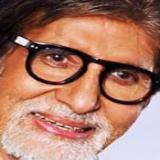

In [15]:
# Read image and show it
from PIL import Image
from IPython.display import display

image = cv2.imread(IMAGE_PATH)

if image is None:
    print("ERROR: Could not read image. Check IMAGE_PATH.")
else:
    print("Image loaded:", IMAGE_PATH)
    display(Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)))


Face detected 


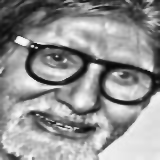

Embedding extracted 


In [16]:
# Extract face and get embedding
face = extract_face(image)

if face is None:
    print("ERROR: No face detected in the image.")
else:
    print("Face detected ")
    display(Image.fromarray(face))
    
    embedding = get_embedding(face)
    
    if embedding is None:
        print("ERROR: Could not extract embedding.")
    else:
        print("Embedding extracted ")


In [17]:
# Predict + record attendance

embedding_lda = lda.transform(np.array(embedding).reshape(1, -1))
predicted_name = svm_model.predict(embedding_lda)[0]

# Confidence score (probability of predicted class)
proba = svm_model.predict_proba(embedding_lda)[0]
confidence = round(max(proba) * 100, 2)

print(f"Predicted: {predicted_name}  (confidence: {confidence}%)")

# Write to CSV 
# Create CSV with header if it doesn't exist
if not os.path.exists(ATTENDANCE):
    with open(ATTENDANCE, mode="w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["name", "date", "time", "confidence"])

# Check if already marked today
today = str(datetime.now().date())
already_marked = False

with open(ATTENDANCE, mode="r") as f:
    reader = csv.reader(f)
    next(reader, None)
    for row in reader:
        if len(row) >= 2 and row[0] == predicted_name and row[1] == today:
            already_marked = True
            break

if already_marked:
    print(f" {predicted_name} already marked today.")
else:
    now = datetime.now()
    with open(ATTENDANCE, mode="a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([predicted_name, today, now.strftime("%H:%M:%S"), f"{confidence}%"])
    print(f" Attendance recorded for {predicted_name}")


Predicted: Amitabh Bachchan  (confidence: 72.46%)
 Attendance recorded for Amitabh Bachchan


In [18]:
# Show the full attendance CSV
import pandas as pd

if os.path.exists(ATTENDANCE):
    df = pd.read_csv(ATTENDANCE)
    print(f"Total records: {len(df)}")
    display(df)
else:
    print("No attendance file yet.")


Total records: 1


,name,date,time,confidence
0,Amitabh Bachchan,2026-05-08,05:38:36,72.46%


## Deleting CSV File 

In [14]:
import os

file = "attendance.csv"

if os.path.exists(file):
    os.remove(file)
    print(" CSV file deleted successfully")
else:
    print("File does not exist")

 CSV file deleted successfully
